# Notebook 03 — Évaluation des modèles pré-entraînés

On teste 2 modèles pré-entraînés (sans fine-tuning) avec 3 stratégies de chunking.
L'objectif est de voir si les embeddings semantiques font mieux que le TF-IDF baseline.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from src.data_utils import load_dataset_fit, group_split
from src.chunking import embed_mean_chunks, score_max_chunks
from src.evaluation import classify, find_best_thresholds, compute_f1

## Chargement et split des données

In [2]:
df = load_dataset_fit()
train_df, test_df = group_split(df)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

Dataset chargé: 8000 paires
Colonnes: ['resume_text', 'job_description_text', 'label']
CVs uniques: 643 pour 8000 paires
Train: 6595 | Test: 1405
Overlap CVs train/test: 0 (doit être 0)
Train: 6595 | Test: 1405


## Chargement des modèles

On utilise 2 modèles pré-entraînés :
- `all-MiniLM-L6-v2` : petit et rapide, 256 tokens max
- `BAAI/bge-small-en-v1.5` : un peu plus grand, 512 tokens max

In [3]:
print("Chargement des modèles...")
model_minilm = SentenceTransformer('all-MiniLM-L6-v2')
model_bge = SentenceTransformer('BAAI/bge-small-en-v1.5')
print("Modèles chargés !")

Chargement des modèles...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Modèles chargés !


## Stratégie 1 : Troncation simple

Le modèle tronque automatiquement les textes trop longs. C'est le comportement par défaut.

In [4]:
# on encode les textes du test set (troncation automatique)
cv_texts = test_df['resume_text'].tolist()
job_texts = test_df['job_description_text'].tolist()

print("Encodage MiniLM (troncation)...")
cv_emb_minilm = model_minilm.encode(cv_texts, show_progress_bar=True, batch_size=32)
job_emb_minilm = model_minilm.encode(job_texts, show_progress_bar=True, batch_size=32)

print("Encodage bge-small (troncation)...")
cv_emb_bge = model_bge.encode(cv_texts, show_progress_bar=True, batch_size=32)
job_emb_bge = model_bge.encode(job_texts, show_progress_bar=True, batch_size=32)

# scores cosinus
scores_minilm_trunc = [
    cosine_similarity([cv_emb_minilm[i]], [job_emb_minilm[i]])[0][0]
    for i in range(len(test_df))
]
scores_bge_trunc = [
    cosine_similarity([cv_emb_bge[i]], [job_emb_bge[i]])[0][0]
    for i in range(len(test_df))
]

print(f"Score moyen MiniLM (troncation): {np.mean(scores_minilm_trunc):.4f}")
print(f"Score moyen bge-small (troncation): {np.mean(scores_bge_trunc):.4f}")

Encodage MiniLM (troncation)...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Encodage bge-small (troncation)...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Batches:   0%|          | 0/44 [00:00<?, ?it/s]

Score moyen MiniLM (troncation): 0.4119
Score moyen bge-small (troncation): 0.6855


In [5]:
# on encode aussi le train set pour calibrer les seuils
print("Encodage train set MiniLM...")
cv_train_minilm = model_minilm.encode(train_df['resume_text'].tolist(), show_progress_bar=True, batch_size=32)
job_train_minilm = model_minilm.encode(train_df['job_description_text'].tolist(), show_progress_bar=True, batch_size=32)

scores_train_minilm = [
    cosine_similarity([cv_train_minilm[i]], [job_train_minilm[i]])[0][0]
    for i in range(len(train_df))
]

print("Encodage train set bge-small...")
cv_train_bge = model_bge.encode(train_df['resume_text'].tolist(), show_progress_bar=True, batch_size=32)
job_train_bge = model_bge.encode(train_df['job_description_text'].tolist(), show_progress_bar=True, batch_size=32)

scores_train_bge = [
    cosine_similarity([cv_train_bge[i]], [job_train_bge[i]])[0][0]
    for i in range(len(train_df))
]

# calibration des seuils sur le train
high_minilm, low_minilm, _ = find_best_thresholds(scores_train_minilm, train_df['label'].tolist())
high_bge, low_bge, _ = find_best_thresholds(scores_train_bge, train_df['label'].tolist())

print(f"Seuils MiniLM: Good Fit >= {high_minilm:.2f}, Potential Fit >= {low_minilm:.2f}")
print(f"Seuils bge-small: Good Fit >= {high_bge:.2f}, Potential Fit >= {low_bge:.2f}")

Encodage train set MiniLM...


Batches:   0%|          | 0/207 [00:00<?, ?it/s]

Batches:   0%|          | 0/207 [00:00<?, ?it/s]

Encodage train set bge-small...


Batches:   0%|          | 0/207 [00:00<?, ?it/s]

Batches:   0%|          | 0/207 [00:00<?, ?it/s]

Seuils MiniLM: Good Fit >= 0.55, Potential Fit >= 0.45
Seuils bge-small: Good Fit >= 0.75, Potential Fit >= 0.70


In [6]:
f1_minilm_trunc = compute_f1(scores_minilm_trunc, test_df['label'].tolist(), high_minilm, low_minilm)
f1_bge_trunc = compute_f1(scores_bge_trunc, test_df['label'].tolist(), high_bge, low_bge)

print(f"F1 MiniLM (troncation): {f1_minilm_trunc:.4f}")
print(f"F1 bge-small (troncation): {f1_bge_trunc:.4f}")

F1 MiniLM (troncation): 0.4475
F1 bge-small (troncation): 0.4599


## Stratégie 2 : Mean pooling des chunks

On découpe les textes en morceaux de ~200 mots, on encode chaque morceau, et on fait la moyenne des embeddings.

In [7]:
print("Mean pooling MiniLM (test)...")
cv_mean_minilm = np.array([embed_mean_chunks(t, model_minilm) for t in cv_texts])
job_mean_minilm = np.array([embed_mean_chunks(t, model_minilm) for t in job_texts])

print("Mean pooling bge-small (test)...")
cv_mean_bge = np.array([embed_mean_chunks(t, model_bge) for t in cv_texts])
job_mean_bge = np.array([embed_mean_chunks(t, model_bge) for t in job_texts])

scores_minilm_mean = [
    cosine_similarity([cv_mean_minilm[i]], [job_mean_minilm[i]])[0][0]
    for i in range(len(test_df))
]
scores_bge_mean = [
    cosine_similarity([cv_mean_bge[i]], [job_mean_bge[i]])[0][0]
    for i in range(len(test_df))
]

# calibrer les seuils sur le train
print("Mean pooling MiniLM (train)...")
cv_train_mean_m = np.array([embed_mean_chunks(t, model_minilm) for t in train_df['resume_text'].tolist()])
job_train_mean_m = np.array([embed_mean_chunks(t, model_minilm) for t in train_df['job_description_text'].tolist()])
scores_train_mean_m = [cosine_similarity([cv_train_mean_m[i]], [job_train_mean_m[i]])[0][0] for i in range(len(train_df))]

print("Mean pooling bge-small (train)...")
cv_train_mean_b = np.array([embed_mean_chunks(t, model_bge) for t in train_df['resume_text'].tolist()])
job_train_mean_b = np.array([embed_mean_chunks(t, model_bge) for t in train_df['job_description_text'].tolist()])
scores_train_mean_b = [cosine_similarity([cv_train_mean_b[i]], [job_train_mean_b[i]])[0][0] for i in range(len(train_df))]

high_mm, low_mm, _ = find_best_thresholds(scores_train_mean_m, train_df['label'].tolist())
high_mb, low_mb, _ = find_best_thresholds(scores_train_mean_b, train_df['label'].tolist())

f1_minilm_mean = compute_f1(scores_minilm_mean, test_df['label'].tolist(), high_mm, low_mm)
f1_bge_mean = compute_f1(scores_bge_mean, test_df['label'].tolist(), high_mb, low_mb)

print(f"F1 MiniLM (mean pooling): {f1_minilm_mean:.4f}")
print(f"F1 bge-small (mean pooling): {f1_bge_mean:.4f}")

Mean pooling MiniLM (test)...
Mean pooling bge-small (test)...
Mean pooling MiniLM (train)...
Mean pooling bge-small (train)...
F1 MiniLM (mean pooling): 0.4332
F1 bge-small (mean pooling): 0.4574


## Stratégie 3 : Max similarity des chunks

On découpe le CV en morceaux, on encode chaque morceau et l'offre entière, et on garde le score maximum.
L'idée : même si un CV est long, au moins un passage devrait être très pertinent.

In [8]:
print("Max similarity MiniLM (test)...")
scores_minilm_max = [score_max_chunks(cv, job, model_minilm) for cv, job in zip(cv_texts, job_texts)]

print("Max similarity bge-small (test)...")
scores_bge_max = [score_max_chunks(cv, job, model_bge) for cv, job in zip(cv_texts, job_texts)]

# calibrer sur le train
print("Max similarity MiniLM (train)...")
scores_train_max_m = [score_max_chunks(cv, job, model_minilm) for cv, job in zip(train_df['resume_text'].tolist(), train_df['job_description_text'].tolist())]

print("Max similarity bge-small (train)...")
scores_train_max_b = [score_max_chunks(cv, job, model_bge) for cv, job in zip(train_df['resume_text'].tolist(), train_df['job_description_text'].tolist())]

high_xm, low_xm, _ = find_best_thresholds(scores_train_max_m, train_df['label'].tolist())
high_xb, low_xb, _ = find_best_thresholds(scores_train_max_b, train_df['label'].tolist())

f1_minilm_max = compute_f1(scores_minilm_max, test_df['label'].tolist(), high_xm, low_xm)
f1_bge_max = compute_f1(scores_bge_max, test_df['label'].tolist(), high_xb, low_xb)

print(f"F1 MiniLM (max similarity): {f1_minilm_max:.4f}")
print(f"F1 bge-small (max similarity): {f1_bge_max:.4f}")

Max similarity MiniLM (test)...
Max similarity bge-small (test)...
Max similarity MiniLM (train)...
Max similarity bge-small (train)...
F1 MiniLM (max similarity): 0.4415
F1 bge-small (max similarity): 0.4727


## Tableau comparatif

On compare tous les résultats. Le score TF-IDF de référence est dans le notebook 02.

In [9]:
# tableau récapitulatif — à remplir avec les vrais résultats
results = {
    'Modèle': ['MiniLM', 'MiniLM', 'MiniLM', 'bge-small', 'bge-small', 'bge-small'],
    'Chunking': ['Troncation', 'Mean pooling', 'Max similarity', 'Troncation', 'Mean pooling', 'Max similarity'],
    'F1 weighted': [
        f1_minilm_trunc, f1_minilm_mean, f1_minilm_max,
        f1_bge_trunc, f1_bge_mean, f1_bge_max
    ]
}

results_df = pd.DataFrame(results)
results_df['F1 weighted'] = results_df['F1 weighted'].round(4)
print(results_df.to_string(index=False))

best_idx = results_df['F1 weighted'].idxmax()
print(f"\nMeilleure combinaison: {results_df.loc[best_idx, 'Modèle']} + {results_df.loc[best_idx, 'Chunking']}")
print(f"F1: {results_df.loc[best_idx, 'F1 weighted']:.4f}")

   Modèle       Chunking  F1 weighted
   MiniLM     Troncation       0.4475
   MiniLM   Mean pooling       0.4332
   MiniLM Max similarity       0.4415
bge-small     Troncation       0.4599
bge-small   Mean pooling       0.4574
bge-small Max similarity       0.4727

Meilleure combinaison: bge-small + Max similarity
F1: 0.4727


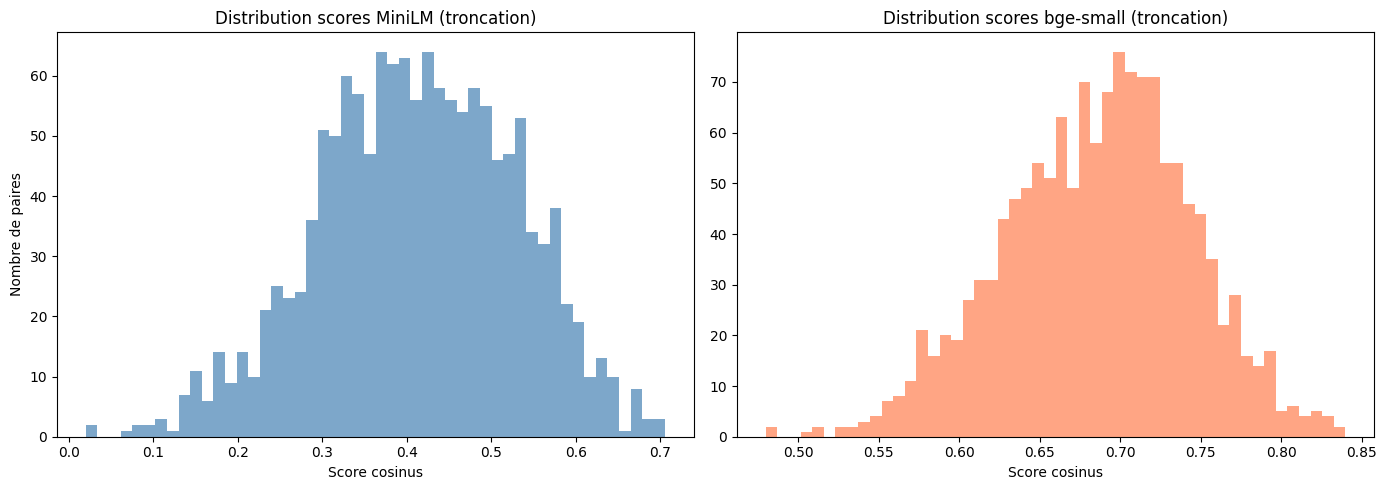

Figure sauvegardée dans figures/


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution des scores MiniLM (troncation)
axes[0].hist(scores_minilm_trunc, bins=50, alpha=0.7, color='steelblue')
axes[0].set_title("Distribution scores MiniLM (troncation)")
axes[0].set_xlabel("Score cosinus")
axes[0].set_ylabel("Nombre de paires")

# distribution des scores bge-small (troncation)
axes[1].hist(scores_bge_trunc, bins=50, alpha=0.7, color='coral')
axes[1].set_title("Distribution scores bge-small (troncation)")
axes[1].set_xlabel("Score cosinus")

plt.tight_layout()
plt.savefig('../figures/pretrained_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée dans figures/")